# Showz

## Exploración de datasets

In [15]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
#Carga de datos
visits = pd.read_csv('datasets/visits_log_us.csv')
orders = pd.read_csv('datasets/orders_log_us.csv')
costs = pd.read_csv('datasets/costs_us.csv')

Definiendo una función de exploración

In [17]:
#Definir una funcion para revisar dataframes
def info_df(df):
    print('___________________________________________ Información de Data Frame')
    print(f'                                                                      *')
    df.info() 
    print('___________________________________________ Primeras tres filas')
    print(f'                                                                      *')
    print(df.head(3))
    if df.duplicated().sum() != 0:
        print('__________________________________*  !!!  *_______ Duplicados *')
        print(f'                                                                      *')
        print(f'Total duplicados: {df.duplicated().sum()}')
        print('__________________________________*   !   *Muestra:')
        if df.duplicated().sum() >= 3:
            print(df[df.duplicated()].sample(3))
        else: 
            print(df[df.duplicated()].sample())
            

In [18]:
print('***   Visitas')
info_df(visits)
print('')
print('***   Pedidos')
info_df(orders)
print('')
print('***   Costos')
info_df(costs)

***   Visitas
___________________________________________ Información de Data Frame
                                                                      *
<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  str   
 1   End Ts     359400 non-null  str   
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  str   
 4   Uid        359400 non-null  uint64
dtypes: int64(1), str(3), uint64(1)
memory usage: 13.7 MB
___________________________________________ Primeras tres filas
                                                                      *
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   

  

La tabla visitas guarda las visitas de los usuarios. De aquí podemos obtener duracion de sesiones, por usuarios, por dispositivos y por fuente.<br> 
La tabla pedidos dice el tiempo de compra y los ingresos por usuario. Este es otro paso del embudo después de las sesiones en la página. De aqui podemos obtener cantidad de compras por usuario y su frecuencia.
La tabla costos dice de que fuente o portal vienen los usuarios y los costos de esa fuente de publicidad ese dia. Esto se puede comparar con los usuarios que se quedan en la pagina en visits y los que realizan pedidos para saber qué es rentable y qué no. 
Las fechas son de tipo object. Deben ser datetime. Además los nombres de las columnas en visits y orders están muy incómodos, estandarizaremos a snake_case.<br>

### Limpieza de datos

In [19]:
#Funcion para snake case de columnas en df
def fun_snkcs(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_')

#Añadir un '_' a ids (gusto personal y claridad)
def fun_id(df, columna, to_id):
    df.rename(columns={columna:f'{to_id}_id'}, inplace=True)

#Cambiar a datetime
def fun_to_dt(df):
    for col in df.columns:
        if col.endswith('_ts') or col == 'dt':
            df[col] = pd.to_datetime(df[col])

#### Visitas

In [20]:
#Uso de la función para snake_case en visits
fun_snkcs(visits)
#uso de función para ids
fun_id(visits, 'uid', 'user')
#uso de función para tipo de datos de fecha
fun_to_dt(visits)

In [21]:
#revisar visits
visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  str           
 1   end_ts     359400 non-null  datetime64[us]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[us]
 4   user_id    359400 non-null  uint64        
dtypes: datetime64[us](2), int64(1), str(1), uint64(1)
memory usage: 13.7 MB


#### Pedidos

In [22]:
#Uso de la función para snake_case en orders
fun_snkcs(orders)
#uso de la funcion de ids
fun_id(orders,'uid', 'user')
#uso de funcion para dateime
fun_to_dt(orders)

In [23]:
#revisar orders
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[us]
 1   revenue  50415 non-null  float64       
 2   user_id  50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


#### Costos

In [24]:
#uso de funcion para dateime
fun_to_dt(costs)

In [25]:
#revisar costs
costs.info()

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[us]
 2   costs      2542 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 59.7 KB


## Preparación de datos

In [26]:
#Definir funcion de estadistica
def distribucion_data(df, columna):
    print('___________________________________________ Descripción estadistica')
    print(f'                                                                      *')
    print(df[columna].describe())
    print('___________________________________________ Dispersión')
    print(f'                                                                      *')
    coef_dispersion = df[columna].std()/df[columna].mean()*100
    mediana = df[columna].median()

    if coef_dispersion < 15:
        print(f'Poca dispersion, {round(coef_dispersion, 3)} %')
    elif coef_dispersion <= 50:
        print(f'Dispersión moderada, {round(coef_dispersion, 3)} %')
    elif coef_dispersion <= 100:
        print(f'Datos muy dispersos, {round(coef_dispersion, 3)} %')
        print(f'La media no representa la mayoria.     * Mediana: {round(mediana,3)}')
    else:
        print(f'Datos extremadamente dispersos, {round(coef_dispersion, 3)} %')
        print(f'La media no representa la mayoria.     * Mediana: {round(mediana,3)}')
    if (df[columna].mean() - round(mediana,3)) > 0:
        print(f'Media - Mediada : {df[columna].mean() - round(mediana,3)}. Sesgo positivo, cola a la derecha')
    elif (df[columna].mean() - round(mediana,3)) < 0:
        print(f'Media - Mediada : {df[columna].mean() - round(mediana,3)}. Sesgo negativo, cola a la izquierda')
    else:
        print('sin sesgo, media=mediana')
    if coef_dispersion <=100 & len(df[columna]) >= 100:
        #histograma
        plt.figure(figsize=(10,2))
        sns.histplot(data=df, x=columna, bins=100, kde=True, alpha=0.5)
        plt.title(f'Histograma de columna: {columna}')
        plt.xlabel(columna)
        plt.ylabel('Frecuencia')
        plt.grid(True)
        plt.show()
    else:
        print('')

Aquí estoy reusando una definición de una función que hice el proyecto pasado, ahora con algunos ajustes. En lugar de bins='fd', que no funciona bien con datos tan dispersos, con 100 bins podemos ver la distribución mucho mejor.

### Visitas

In [27]:
#para recordar las columnas
visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  str           
 1   end_ts     359400 non-null  datetime64[us]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[us]
 4   user_id    359400 non-null  uint64        
dtypes: datetime64[us](2), int64(1), str(1), uint64(1)
memory usage: 13.7 MB


Hay 359400 registros de visitas como tamaño de muestra. <br>
Extraemos los componentes de fecha en nuevas columnas.

In [28]:
#Componentes de fechas
visits['date'] = visits['start_ts'].dt.date
visits['month'] = visits['start_ts'].dt.month
visits['year'] = visits['start_ts'].dt.year
visits['week'] = visits['start_ts'].dt.isocalendar().week

#Añadimos una columna con la duración de cada visita

In [34]:

visits['duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.seconds

In [35]:
print(f"La primer fecha registrada es {visits['start_ts'].min()} y la última es {visits['start_ts'].max()}")

La primer fecha registrada es 2017-06-01 00:01:00 y la última es 2018-05-31 23:59:00


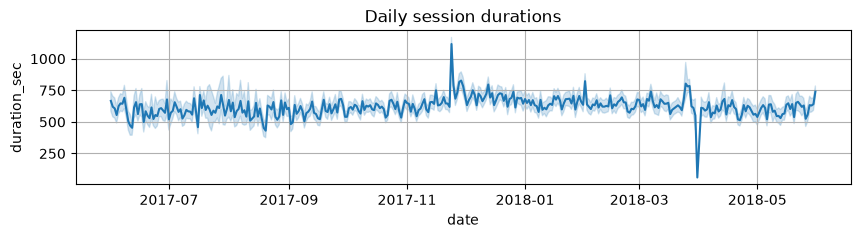

In [36]:
#gráfico de duración de sesiones
#Grafico de Duracion de sesiones
plt.figure(figsize=(10,2))
#Gráfico de lineas
sns.lineplot(data=visits, x='date', y='duration_sec')
plt.title('Daily session durations')
plt.grid(True)
plt.show()

In [37]:
#uso de función de datos estadisticos
distribucion_data(visits, 'duration_sec')

___________________________________________ Descripción estadistica
                                                                      *
count    359400.000000
mean        643.506489
std        1016.334786
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       84480.000000
Name: duration_sec, dtype: float64
___________________________________________ Dispersión
                                                                      *
Datos extremadamente dispersos, 157.937 %
La media no representa la mayoria.     * Mediana: 300.0
Media - Mediada : 343.506488592098. Sesgo positivo, cola a la derecha



La duración de la sesiones en promedio duraron 643.51 segundos, pero la media muestra 300 segundos. Hay muchos valores extremos. Pero se puede ver en el percentil 75% que es en el último en el que la duración de las sesiones crece muchísimo por outliers. La desviación estándar es 1016, y están tan dispersos que el valor medio es 300 y la media es casi el doble, 643 segundos.


¿Cuántas personas lo usan cada día, semana y mes?
¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
¿Cuál es la duración de cada sesión?
¿Con qué frecuencia los usuarios regresan?

In [ ]:
#Métricas de actividad de usuarios
#al día
dau = visits.groupby('date').agg({'user_id': 'nunique'})
wau = visits.groupby(['year', 'week']).agg({'user_id': 'nunique'})
mau = visits.groupby(['year', 'month']).agg({'user_id': 'nunique'})
#index
dau_plot = dau.reset_index()
wau_plot = wau.reset_index()
mau_plot = mau.reset_index()

Se usa el metodo nunique para contar las incidencias únicas de cada usuario, y señalamos el año en la agrupación para que la información corresponda al mes correcto.

In [ ]:
#Gráfico DAU
plt.figure(figsize=(10,2))
#Gráfico de lineas
sns.lineplot(data=dau_plot, x='date', y='user_id')
plt.title('Daily Active Users')
plt.grid(True)
plt.show()

In [ ]:
distribucion_data(dau_plot, 'user_id')

En la gráfica de líneas de daily se ven picos interesantes. Entre noviembre 2017 y enero 2018, y de 2018, entre marzo y mayo. <br>
En el histograma vemos la frecuencia de usuarios diarios. En promedio hubo 907.99 usuarios diarios desde 2017 a 2018. En general, lo más frecuente era ver entre 500 y 1500 usuarios diarios, pero hubo algunos casos, menos de 5, donde se registró más de 3000 usuarios diarios.<br>
En el gráfico de líneas podemos ver que este pico de más de 3000 visitas diarias sucedió entre noviembre de 2017 y enero 2018, además, en esas fechas también se registraron las sesiones con duraciones más largas.

In [ ]:
#Gráfico MAU
plt.figure(figsize=(10,2))
#Gráfico de lineas
sns.lineplot(data=mau_plot, x='month', y='user_id', hue='year')
plt.title('Monthly Active Users')
plt.grid(True)
plt.show()

In [ ]:
#funcion de distribución para los usuarios activos cada mes
distribucion_data(mau_plot, 'user_id')

In [ ]:
print(f"En promedio hay {dau['user_id'].mean():.2f} usuarios diarios y {wau['user_id'].mean():.2f} usuarios por semana")
print(f"Por mes, en promedio hay {mau['user_id'].mean():.2f} usuarios")

Desde agosto de 2017 a diciembre hay un crecimiento en la cantidad de usuarios, pero en 2018 hay una caida de febrero a abril. 

### Ventas

¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)
¿Cuántos pedidos hacen durante un período de tiempo dado?
¿Cuál es el tamaño promedio de compra?
¿Cuánto dinero traen? (LTV)

### Marketing

¿Cuánto dinero se gastó? (Total/por fuente de adquisición/a lo largo del tiempo)
¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
¿Cuán rentables eran las inversiones? (ROMI)

### Comparación de dispositivos

Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo.

## Conclusión

aconseja a los expertos de marketing cuánto dinero invertir y dónde ¿Qué fuentes/plataformas recomendarías? Fundamenta tu selección: ¿en qué métricas te enfocaste? ¿Por qué? ¿Qué conclusiones sacaste después de encontrar los valores métricos?